# Noise Parcel Simulation

Does a noise parcel help recover the true Vs when some voxels are noise?


To test this, I simualate data, where some voxels are pure noise (with different proportions of noise out of all voxels). I then fit models with and without a noise parcel, and with and without parcel-specific kappa.

**4 models** (all with K=10 real parcels):
1. MixVMF, single kappa
2. MixVMF, parcel-specific kappa
3. MixVMFNoise (+ noise parcel), single kappa
4. MixVMFNoise (+ noise parcel), parcel-specific kappa

In [8]:
import numpy as np
import torch as pt
import pandas as pd
import matplotlib.pyplot as plt
import HierarchBayesParcel.arrangements as ar
import HierarchBayesParcel.emissions as em
import HierarchBayesParcel.full_model as fm
import HierarchBayesParcel.evaluation as ev
import HierarchBayesParcel.util as hut

In [ ]:
# consts
K = 10 
P = 300 
M = 15
n_subj = 5
n_part = 2
kappa_true = 15 # this is approx equal to the avg kappa across emissions for a cortical parcellation
rho_values = [0, 0.1, 0.2, 0.3, 0.4, 0.5,0.6,0.7]
n_rep = 20  # repetitions per rho

part_vec = pt.kron(pt.arange(n_part), pt.ones(M,))
cond_vec = pt.kron(pt.ones(n_part,), pt.arange(M))
X = pt.tensor(hut.indicator(cond_vec), dtype=pt.float32)

In [10]:
def generate_data(V_true, rho):
    """Generate data with K real parcels + rho fraction noise using MixVMFNoise.sample()."""
    K_total = K + 1
    arrange = ar.ArrangeIndependent(K_total, P, spatial_specific=True, remove_redundancy=False)
    logpi = pt.full((K_total, P), np.log((1 - rho) / K))
    logpi[K, :] = np.log(rho)
    if rho == 0:
        logpi = pt.full((K_total, P), np.log(1.0 / K))
        logpi[K, :] = -100 # if rho is 0, noise parcel should have 0 probability
    arrange.logpi = logpi
    U = arrange.sample(num_subj=n_subj)

    # MixVMFNoise.sample() — handles real parcels + noise voxels
    emission = em.MixVMFNoise(K=K_total, P=P, X=X, part_vec=part_vec)
    emission.V = V_true
    emission.kappa = pt.tensor(kappa_true, dtype=pt.float32)
    Y = emission.sample(U)
    return Y


def fit_model(Y, emission):
    K_fit = emission.K
    model = fm.FullMultiModel(ar.ArrangeIndependent(K_fit, P, spatial_specific=True, remove_redundancy=False),[emission])
    model.initialize([Y], subj_ind=[np.arange(n_subj)])
    model, ll, *_ = model.fit_em_ninits(iter=100, tol=0.01,
                                        fit_arrangement=True, fit_emission=True,
                                        init_arrangement=True, init_emission=True,
                                        n_inits=20, first_iter=15, verbose=False)
    return model


def v_recovery(V_fit, V_true):
    """Mean cosine similarity after greedy alignment"""
    K = V_fit.shape[1]
    idx = ev.matching_greedy(V_true[:, :K].T, V_fit[:, :K].T)
    V_aligned = V_fit[:, idx]
    V_aligned_norm = V_aligned / pt.sqrt((V_aligned ** 2).sum(dim=0))
    V_true_norm = V_true[:, :K] / pt.sqrt((V_true[:, :K] ** 2).sum(dim=0))
    cos = (V_aligned_norm * V_true_norm).sum(dim=0)
    return cos.mean().item()

In [11]:
# simulation
model_names = [
    'MixVMF',
    'MixVMF (parcel kappa)',
    'MixVMFNoise',
    'MixVMFNoise (parcel kappa)',
]


results = {name: {rho: [] for rho in rho_values} for name in model_names}

for rho in rho_values:
    print(f"Simulating for rho={rho}...")
    for rep in range(n_rep):
        V_true = pt.randn(M, K)
        V_true = V_true / pt.sqrt((V_true ** 2).sum(dim=0))

        Y = generate_data(V_true, rho)

        emissions = {
            'MixVMF': em.MixVMF(K=K, P=P, X=X, part_vec=part_vec),
            'MixVMF (parcel kappa)': em.MixVMF(K=K, P=P, X=X, part_vec=part_vec,
                                                parcel_specific_kappa=True),
            'MixVMFNoise': em.MixVMFNoise(K=K+1, P=P, X=X, part_vec=part_vec),
            'MixVMFNoise (parcel kappa)': em.MixVMFNoise(K=K+1, P=P, X=X, part_vec=part_vec,
                                                        parcel_specific_kappa=True),
        }

        for name, emission in emissions.items():
            m = fit_model(Y, emission)
            V_fit = m.emissions[0].V.detach()
            rec = v_recovery(V_fit, V_true)
            results[name][rho].append(rec)



Simulating for rho=0...


C:\Users\barafat\AppData\Local\Temp\ipykernel_1476\2739228619.py:6: RuntimeWarning: divide by zero encountered in log
  logpi[K, :] = np.log(rho)
C:\Users\barafat\Documents\GitHub\HierarchBayesParcel\HierarchBayesParcel\emissions.py:346: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.part_vec = pt.tensor(part_vec, dtype=pt.int)


Likelihood decreased - terminating on iteration 2
Likelihood decreased - terminating on iteration 10
Likelihood decreased - terminating on iteration 21
Likelihood decreased - terminating on iteration 7
Likelihood decreased - terminating on iteration 9
Likelihood decreased - terminating on iteration 12
Likelihood decreased - terminating on iteration 10
Likelihood decreased - terminating on iteration 7
Likelihood decreased - terminating on iteration 7
Likelihood decreased - terminating on iteration 3
Likelihood decreased - terminating on iteration 6
Likelihood decreased - terminating on iteration 8
Likelihood decreased - terminating on iteration 3
Likelihood decreased - terminating on iteration 11
Likelihood decreased - terminating on iteration 11
Likelihood decreased - terminating on iteration 29
Likelihood decreased - terminating on iteration 9
Likelihood decreased - terminating on iteration 17
Likelihood decreased - terminating on iteration 8
Likelihood decreased - terminating on iter

In [ ]:
# rows = []
# for name in model_names:
#     for rho in rho_values:
#         for i, val in enumerate(results[name][rho]):
#             rows.append({'model': name, 'rho': rho, 'rep': i, 'v_recovery': val})

# df = pd.DataFrame(rows)
# df.to_csv('sim_vmfnoise.tsv', sep='\t', index=False)

In [13]:
df = pd.read_csv('sim_vmfnoise.tsv', sep='\t')

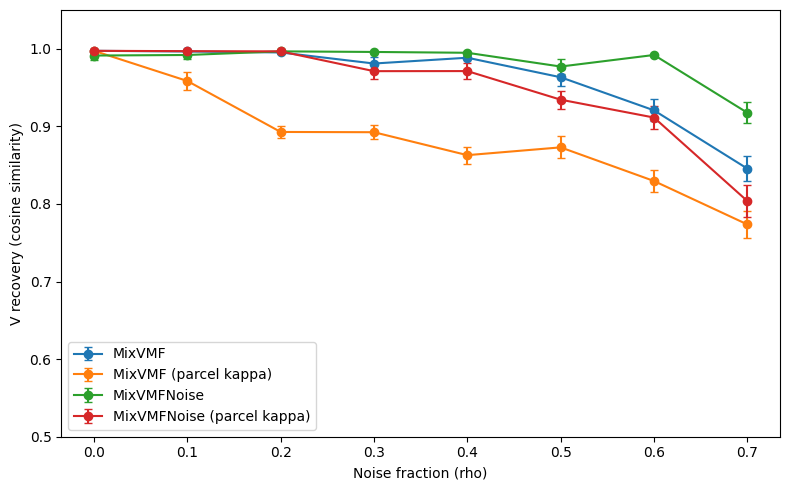

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
for name in model_names:
    dm = df[df.model == name]
    means = dm.groupby('rho').v_recovery.mean()
    sems = dm.groupby('rho').v_recovery.sem()
    ax.errorbar(means.index, means.values, yerr=sems.values, marker='o', label=name, capsize=3)
ax.set_xlabel('Noise fraction (rho)')
ax.set_ylabel('V recovery (cosine similarity)')
ax.set_ylim(0.5, 1.05)
ax.legend()
plt.tight_layout()
plt.show()


MixVMFNoise wins or is just as good as mixVMF at high kappa. Parcel specfic kappa always the worst